# Rainfall Prediction using Machine Learning
**Internship Project — Zephyr Technologies and Solutions Pvt Ltd**

This notebook follows the pipeline in the project report:
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Selection
6. Model Training
7. Model Evaluation
8. Save Model

**Note:** DISTRICT is used only as a raw latitude/longitude pair, not as a
fixed named category — a label encoder for district names only recognizes
the exact names it was trained on, so using LATITUDE/LONGITUDE instead lets
the trained model generalize to any location, not just the ones in this
dataset. See `../api/predict_live.py` for a script that predicts rainfall
for any place in the world using this same model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

## 1. Data Collection
Load the historical weather dataset.

In [2]:
df = pd.read_csv("../dataset/rainfall_dataset.csv")
print(df.shape)
df.head()

(10950, 20)


   YEAR  MO  DY   RH2M  ...       WSC         DISTRICT  LATITUDE  LONGITUDE
0  2022   6  17  78.54  ...  Moderate            Kolar   13.1372    78.1298
1  2025  12  31  69.84  ...  Moderate  Bengaluru Urban   12.9716    77.5946
2  2025  12   1  62.15  ...  Moderate       Ramanagara   12.7217    77.2812
3  2022   6   3  79.16  ...  Moderate  Bengaluru Urban   12.9716    77.5946
4  2023   6  13  79.39  ...  Moderate   Chikkaballapur   13.4355    77.7315

[5 rows x 20 columns]

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10950 entries, 0 to 10949
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 10950 non-null  int64  
 1   MO                   10950 non-null  int64  
 2   DY                   10950 non-null  int64  
 3   RH2M                 10950 non-null  float64
 4   T2MDEW               10950 non-null  float64
 5   QV2M                 10950 non-null  float64
 6   PS                   10950 non-null  float64
 7   WS50M                10950 non-null  float64
 8   PRECTOTCORR          10950 non-null  float64
 9   T2MWET               10950 non-null  float64
 10  WD50M                10950 non-null  float64
 11  T2M_MAX              10950 non-null  float64
 12  T2M_MIN              10950 non-null  float64
 13  ALLSKY_SFC_UV_INDEX  10950 non-null  float64
 14  TS                   10950 non-null  float64
 15  PSC                  10950 non-null  str    
 1

## 2. Data Preprocessing

### 2a. Check missing values

In [4]:
df.isnull().sum()

YEAR                   0
MO                     0
DY                     0
RH2M                   0
T2MDEW                 0
QV2M                   0
PS                     0
WS50M                  0
PRECTOTCORR            0
T2MWET                 0
WD50M                  0
T2M_MAX                0
T2M_MIN                0
ALLSKY_SFC_UV_INDEX    0
TS                     0
PSC                    0
WSC                    0
DISTRICT               0
LATITUDE               0
LONGITUDE              0
dtype: int64

### 2b. Label Encoding for PSC and WSC
These are text categories (e.g. 'Low'/'Medium'/'High' pressure), so we convert them to numbers.
DISTRICT is intentionally **not** label-encoded as a category — see the note at the top of this notebook.

In [5]:
le_psc = LabelEncoder()
df['PSC_ENC'] = le_psc.fit_transform(df['PSC'])

le_wsc = LabelEncoder()
df['WSC_ENC'] = le_wsc.fit_transform(df['WSC'])

df[['PSC', 'PSC_ENC', 'WSC', 'WSC_ENC']].head()

      PSC  PSC_ENC       WSC  WSC_ENC
0    High        0  Moderate        1
1     Low        1  Moderate        1
2  Medium        2  Moderate        1
3  Medium        2  Moderate        1
4    High        0  Moderate        1

### 2c. Create the target variable — Rainfall_Class
Built from PRECTOTCORR (corrected total precipitation): 1 if it rained, 0 if not.

In [6]:
df['Rainfall_Class'] = (df['PRECTOTCORR'] > 0).astype(int)
df['Rainfall_Class'].value_counts()

Rainfall_Class
0    7560
1    3390
Name: count, dtype: int64

### 2d. Features and target
PRECTOTCORR is dropped (the target is derived from it — keeping it would leak the answer).
DISTRICT's *name* is dropped too; its LATITUDE/LONGITUDE are used instead, so the
model works for any location rather than only the districts seen during training.

Columns are selected in an explicit, fixed order — scikit-learn requires the
exact same column order at prediction time as during training.

In [7]:
FEATURE_ORDER = [
    "YEAR", "MO", "DY", "RH2M", "T2MDEW", "QV2M", "PS", "WS50M",
    "T2MWET", "WD50M", "T2M_MAX", "T2M_MIN", "ALLSKY_SFC_UV_INDEX", "TS",
    "PSC_ENC", "WSC_ENC", "LATITUDE", "LONGITUDE",
]
X = df[FEATURE_ORDER]
y = df['Rainfall_Class']
X.head()

   YEAR  MO  DY   RH2M  T2MDEW  ...     TS  PSC_ENC  WSC_ENC  LATITUDE  LONGITUDE
0  2022   6  17  78.54   23.50  ...  28.87        0        1   13.1372    78.1298
1  2025  12  31  69.84   20.91  ...  29.11        1        1   12.9716    77.5946
2  2025  12   1  62.15   23.37  ...  32.27        2        1   12.7217    77.2812
3  2022   6   3  79.16   22.46  ...  27.01        2        1   12.9716    77.5946
4  2023   6  13  79.39   26.84  ...  29.96        0        1   13.4355    77.7315

[5 rows x 18 columns]

### 2e. Train / test split (80% / 20%)
Split **before** scaling, so no information from the test set leaks into training.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (8760, 18)  Test: (2190, 18)


### 2f. Feature scaling
StandardScaler is fit on the training data only, then applied to both sets.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Exploratory Data Analysis (EDA)

### Rainfall Class Count

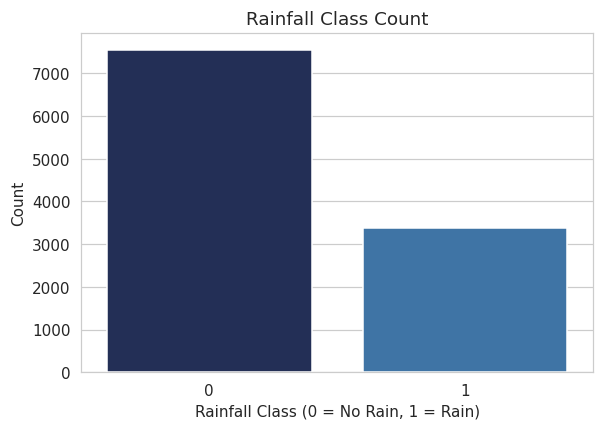

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Rainfall_Class', data=df, hue='Rainfall_Class',
              palette=['#1B2A5E','#2E75B6'], legend=False)
plt.title('Rainfall Class Count')
plt.xlabel('Rainfall Class (0 = No Rain, 1 = Rain)')
plt.ylabel('Count')
plt.savefig('../graphs/Rainfall_Class_Count.png', dpi=150, bbox_inches='tight')
plt.show()

### Rainfall Distribution

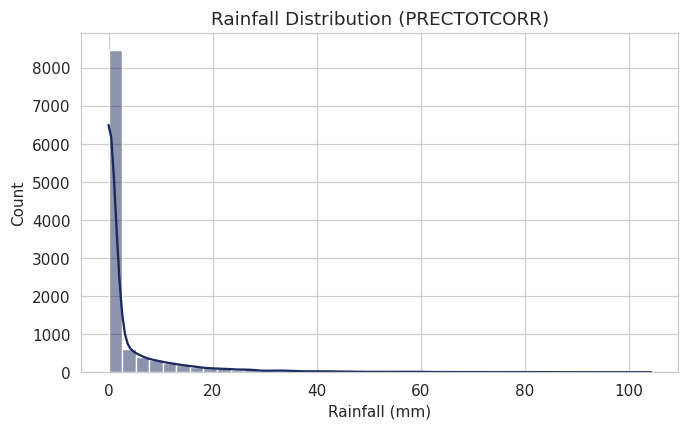

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, color='#1B2A5E')
plt.title('Rainfall Distribution (PRECTOTCORR)')
plt.xlabel('Rainfall (mm)')
plt.savefig('../graphs/Rainfall_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Correlation Heatmap

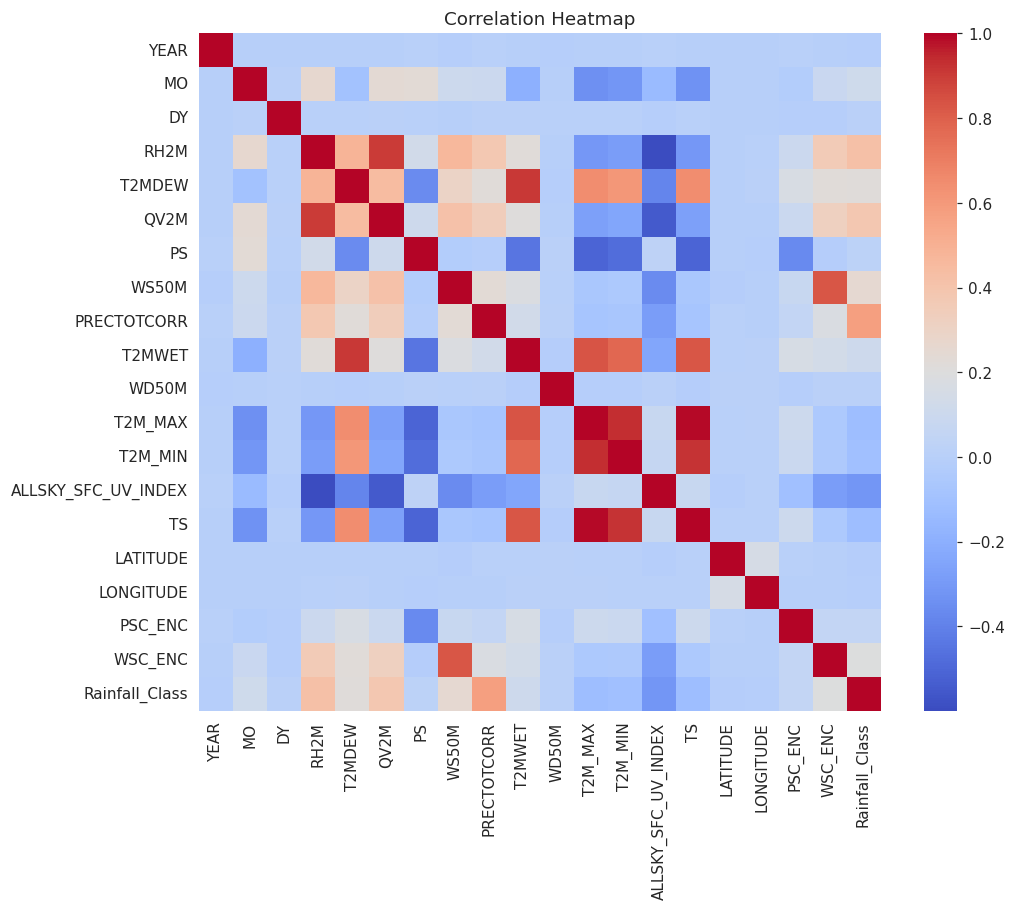

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['DISTRICT','PSC','WSC']).corr(numeric_only=True),
            cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.savefig('../graphs/Correlation_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Selection
All remaining weather, time and location features are used as input variables.

In [13]:
print(list(X.columns))

['YEAR', 'MO', 'DY', 'RH2M', 'T2MDEW', 'QV2M', 'PS', 'WS50M', 'T2MWET', 'WD50M', 'T2M_MAX', 'T2M_MIN', 'ALLSKY_SFC_UV_INDEX', 'TS', 'PSC_ENC', 'WSC_ENC', 'LATITUDE', 'LONGITUDE']


## 5 & 6. Model Selection and Training
Three classification models are trained and compared, as in the report.

In [14]:
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", results['Logistic Regression'])

Logistic Regression Accuracy: 0.7598173515981735


In [15]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=8)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", results['Decision Tree'])

Decision Tree Accuracy: 0.7506849315068493


In [16]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", results['Random Forest'])

Random Forest Accuracy: 0.7570776255707763


## 7. Model Evaluation

In [17]:
for name, acc in results.items():
    print(f"{name}: {acc*100:.2f}%")

best_model_name = max(results, key=results.get)
best_pred = {'Logistic Regression': y_pred_lr, 'Decision Tree': y_pred_dt, 'Random Forest': y_pred_rf}[best_model_name]
best_model = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}[best_model_name]
print(f"\nBest model: {best_model_name}  ({results[best_model_name]*100:.2f}%)")

Logistic Regression: 75.98%
Decision Tree: 75.07%
Random Forest: 75.71%

Best model: Logistic Regression  (75.98%)


### Classification Report

In [18]:
print(classification_report(y_test, best_pred, target_names=['No Rain','Rain']))

              precision    recall  f1-score   support

     No Rain       0.80      0.86      0.83      1512
        Rain       0.63      0.53      0.58       678

    accuracy                           0.76      2190
   macro avg       0.72      0.70      0.71      2190
weighted avg       0.75      0.76      0.75      2190



### Confusion Matrix

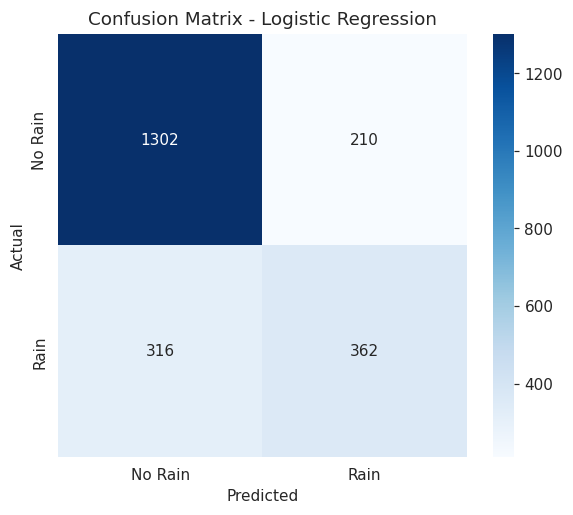

In [19]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain','Rain'], yticklabels=['No Rain','Rain'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../graphs/Confusion_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Accuracy Comparison

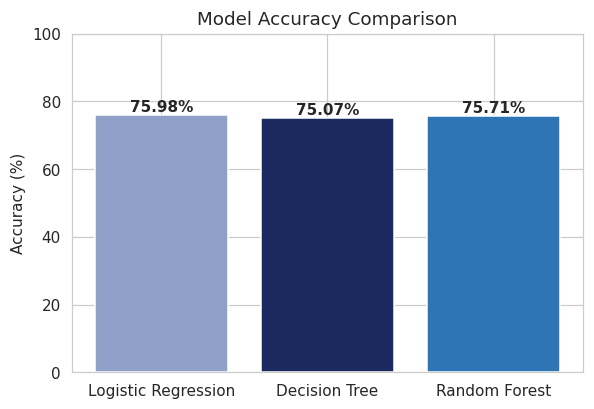

In [20]:
plt.figure(figsize=(6,4))
plt.bar(results.keys(), [v*100 for v in results.values()], color=['#8FA0C8','#1B2A5E','#2E75B6'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0,100)
for i, v in enumerate(results.values()):
    plt.text(i, v*100+1, f"{v*100:.2f}%", ha='center', fontweight='bold')
plt.savefig('../graphs/Model_Accuracy_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save the Best Model

In [21]:
with open(f"../models/{best_model_name.lower().replace(' ','_')}_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("../models/label_encoder_psc.pkl", "wb") as f:
    pickle.dump(le_psc, f)
with open("../models/label_encoder_wsc.pkl", "wb") as f:
    pickle.dump(le_wsc, f)

print("Model saved successfully.")

Model saved successfully.


## 9. Predict on New Data (example)
This example reuses a row from the test set. For a real location typed in by
name (not just this dataset's 5 districts), see `../api/predict_live.py`.

In [22]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
prediction = best_model.predict(sample_scaled)[0]
print("Predicted Rainfall Class:", "Rain" if prediction == 1 else "No Rain")
print("Actual Rainfall Class:", "Rain" if y_test.iloc[0] == 1 else "No Rain")

Predicted Rainfall Class: No Rain
Actual Rainfall Class: No Rain
